In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
import tqdm.auto as tqdm
from scipy.stats import spearmanr, kendalltau, pearsonr
from sklearn.metrics import ndcg_score
from functools import namedtuple
from joblib import Parallel, delayed

from IPython.display import display, Markdown

from dti.constants import PREDICTION
from dti.utils import Method, read_predictions

In [2]:
predictions = read_predictions(pathlib.Path("../data/hpc-data/"))

0it [00:00, ?it/s]

no predictions file in ../data/hpc-data/output
no predictions file in ../data/hpc-data/1744365539.9267464
no predictions file in ../data/hpc-data/1744542228.080247


In [3]:
predictions

,prediction,target,compound_id,assay_id,method,fold,dataset
0,-0.478932,-0.600633,2492752,2069125,Random SetRank,0,landrum
1,0.619384,1.166805,2489604,2069125,Random SetRank,0,landrum
2,-0.538258,0.603727,2493469,2069125,Random SetRank,0,landrum
3,1.879495,1.307574,2509683,2069125,Random SetRank,0,landrum
4,-1.296679,0.635009,2498062,2069125,Random SetRank,0,landrum
...,...,...,...,...,...,...,...
159904,7.184952,-1.870227,331845,325278,Assay SetRank,4,omnivore
159905,16.352186,-0.159757,331861,325278,Assay SetRank,4,omnivore
159906,4.410152,-1.862757,331665,325278,Assay SetRank,4,omnivore
159907,-8.841320,-1.384722,331839,325278,Assay SetRank,4,omnivore


<Axes: xlabel='prediction', ylabel='Density'>

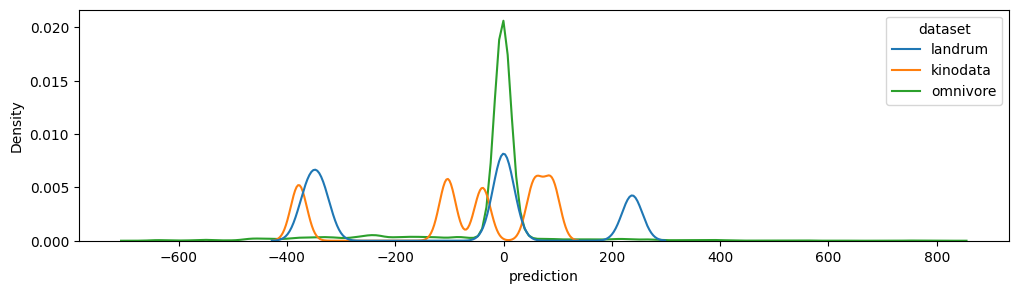

In [4]:
plt.figure(figsize=(12, 3))
sns.kdeplot(
    predictions[predictions["method"] == Method.SETS],
    x=PREDICTION,
    hue="dataset",
    common_norm=False,
)

In [5]:
def enrichment(pred, truth, fraction):
    if not (0 < fraction <= 1):
        raise ValueError("Fraction should be between 0 and 1.")

    pred = np.array(pred)
    truth = np.array(truth)

    num_total = len(truth)
    num_actives = int(np.ceil(num_total * fraction))

    if num_actives == 0:
        return 0.0

    truth_threshold = np.partition(truth, -num_actives)[-num_actives]

    binary_truth = (truth >= truth_threshold).astype(int)
    sorted_indices = np.argsort(pred)[::-1]
    sorted_truth = binary_truth[sorted_indices]
    num_actives_top = np.sum(sorted_truth[:num_actives])

    ef = (num_actives_top / num_actives) / (np.mean(binary_truth))
    assert ef >= 0
    return ef

In [6]:
predictions["method"] = list(map(str, predictions["method"]))

In [7]:
def mrr(pred, tgt):
    i = np.argmax(tgt)
    return 1 / (1 + np.argsort(pred)[i])


# def ap(tgt, pred):

In [8]:
def compute_average_precision(y_true: np.ndarray, y_scores: np.ndarray) -> float:
    """
    Compute the average precision (AP) by integrating over the precision-recall curve.

    Parameters:
    y_true (np.ndarray): Continuous ground truth values.
    y_scores (np.ndarray): Predicted scores.

    Returns:
    float: The average precision score.
    """
    # Sort by descending prediction score
    sorted_indices = np.argsort(-y_scores)
    y_true_sorted = y_true[sorted_indices]

    # Compute precision and recall
    cumsum_true = np.cumsum(y_true_sorted)
    recall = cumsum_true / np.sum(y_true)  # Recall at each threshold
    precision = cumsum_true / (
        np.arange(1, len(y_true) + 1)
    )  # Precision at each threshold

    # Compute average precision using trapezoidal rule
    ap = np.sum((recall[1:] - recall[:-1]) * precision[1:])

    return ap


# Example usage:
y_true = np.array([0.2, 0.4, 0.8, 0.9, 0.5, 0.1, 0.7])  # Continuous ground truth
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.65, 0.2, 0.9])  # Predicted scores

ap_score = compute_average_precision(y_true, y_scores)
print("Average Precision:", ap_score)

Average Precision: 0.5576455026455026


In [9]:
ndcg_score([[1, 2, 3]], [[3, 2, 3]])

np.float64(0.894999002123018)

In [10]:
keys = ["dataset", "assay_id", "method", "fold"]
Row = namedtuple(
    "Row",
    keys
    + [
        "size",
        "ndcg",
        "ap",
        "mrr",
        "pearson",
        "spearman",
        "kendall",
        "ef_1",
        "ef_5",
        "ef_10",
    ],
)


def proc(args):
    feats, group = args
    pred, tgt = group[PREDICTION], group["target"]
    if len(group) < 3 or tgt.nunique() <= 1 or pred.nunique() <= 1:
        return None
    ndcg = ndcg_score(np.argsort(tgt.values).reshape(1, -1), pred.values.reshape(1, -1))
    ap = compute_average_precision(tgt.values, pred.values)
    pr = pearsonr(pred, tgt).statistic
    mr = mrr(pred.values, tgt.values)
    kt = kendalltau(pred, tgt).statistic
    sr = spearmanr(pred, tgt).statistic
    ef_1 = enrichment(pred, tgt, 0.01)
    ef_5 = enrichment(pred, tgt, 0.05)
    ef_10 = enrichment(pred, tgt, 0.1)

    return Row(
        *(list(feats) + [len(group), ndcg, ap, mr, pr, sr, kt, ef_1, ef_5, ef_10])
    )


performance = Parallel(n_jobs=8)(
    map(delayed(proc), tqdm.tqdm(predictions.groupby(keys)))
)
# performance = [proc(g) for g in tqdm.tqdm(predictions.groupby(keys))]
performance = pd.DataFrame([p for p in performance if p is not None])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (777732155.py, line 24)

In [ ]:
keys = ["dataset", "method", "fold"]
Row = namedtuple(
    "Row",
    keys
    + [
        "size",
        "ndcg",
        "ap",
        "mrr",
        "pearson",
        "spearman",
        "kendall",
        "ef_1",
        "ef_5",
        "ef_10",
    ],
)
rows = list()
for feats, group in tqdm.tqdm(performance.groupby(keys)):
    if len(group) <= 3:
        continue
    weights = group["size"] - 3
    sr = (
        np.atanh(np.clip(group["spearman"], 1e-7 - 1, 1 - 1e-7)) * weights
    ).sum() / weights.sum()
    pr = (
        np.atanh(np.clip(group["pearson"], 1e-7 - 1, 1 - 1e-7)) * weights
    ).sum() / weights.sum()
    n = group["size"].sum()
    ndcg = (group["ndcg"] * group["size"]).sum() / n
    ap = (group["ap"] * group["size"]).sum() / n
    kt = (group["kendall"] * group["size"]).sum() / n
    mr = (group["mrr"] * group["size"]).sum() / n
    ef10 = (group["ef_10"] * group["size"]).sum() / n
    ef5 = (group["ef_5"] * group["size"]).sum() / n
    ef1 = (group["ef_1"] * group["size"]).sum() / n
    rows.append(Row(*(list(feats) + [n, ndcg, ap, mr, pr, sr, kt, ef1, ef5, ef10])))
overall_perf = pd.DataFrame(rows)

In [ ]:
hue_order = ["IC50", "Random SetRank", "Assay SetRank"]
col_order = ["kinodata", "landrum", "omnivore"]
for metric in [
    "ndcg",
    "ap",
    "mrr",
    "pearson",
    "spearman",
    "kendall",
    "ef_1",
    "ef_5",
    "ef_10",
]:
    display(Markdown(f"# {metric}"))
    fig = plt.figure()
    g = sns.catplot(
        overall_perf,
        y=metric,
        col="dataset",
        hue="method",
        x="method",
        kind="box",
        sharey=False,
        order=hue_order,
        col_order=col_order,
        legend=False,
    )
    g.despine(bottom=True)
    g.set_xlabels(label="")
    plt.show()